## Projet : InnoMoov — Détection du risque de panne machine

InnoMoov est une entreprise orientée mobilité intelligente et Industrie 4.0. Elle exploite une usine connectée où les machines, les capteurs IoT, le MES et l’ERP échangent des données pour améliorer la production, la qualité et la disponibilité des équipements.

Dans ce TP, on se place dans le rôle d’une équipe Data Science chargée de développer un modèle de classification supervisée capable de prédire si une machine présente un risque de panne.

## Besoin industriel

Dans l’usine InnoMoov, les arrêts non planifiés dégradent directement la disponibilité machine, le TRS et la capacité à respecter les délais de production. Une panne peut provoquer :

- un arrêt de ligne ;
- une baisse du taux de rendement synthétique ;
- des retards de livraison ;
- une augmentation des coûts de maintenance ;
- une dégradation de la qualité des produits.

L’objectif est donc de mettre en place un modèle de Machine Learning capable de classer automatiquement l’état d’une machine :

- **0 : fonctionnement normal**
- **1 : risque de panne**

## Objectifs du notebook

Ce notebook répond aux étapes du TP :

1. déterminer un besoin industriel ;
2. récupérer un dataset lié à ce besoin ;
3. utiliser la carte d’orientation Scikit-Learn pour choisir un algorithme de classification ;
4. afficher le score du modèle et tracer sa frontière de décision ;
5. utiliser le modèle pour faire des prédictions et expliquer son intérêt dans le process industriel.

## Dataset utilisé

Le dataset utilisé est le dataset **AI4I 2020 Predictive Maintenance**. Il contient des données simulant un contexte industriel réaliste avec des mesures issues de machines :

- température de l’air ;
- température du process ;
- vitesse de rotation ;
- couple ;
- usure outil ;
- type de produit ;
- indicateur de panne machine.

La variable cible du TP est :

`Machine failure`

Elle indique si une machine est en situation normale ou en panne.

---

In [2]:
# ============================================================
# 1. IMPORTS, CONFIGURATION ET CHARGEMENT DU DATASET
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Configuration graphique personnalisée
# ------------------------------------------------------------

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.facecolor"] = "#F7F3EC"
plt.rcParams["figure.facecolor"] = "#F7F3EC"
plt.rcParams["axes.edgecolor"] = "#2F2F2F"
plt.rcParams["axes.labelcolor"] = "#2F2F2F"
plt.rcParams["xtick.color"] = "#2F2F2F"
plt.rcParams["ytick.color"] = "#2F2F2F"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"

palette_innomoov = {
    "normal": "#2E8B57",
    "failure": "#C94C4C",
    "accent": "#C87941",
    "dark": "#232323",
    "blue": "#3A6EA5",
    "sand": "#D8C3A5"
}

# ------------------------------------------------------------
# Chargement du dataset AI4I 2020 Predictive Maintenance
# Version locale du fichier
# ------------------------------------------------------------

df = pd.read_csv("ai4i2020.csv")

# Nettoyage simple des noms de colonnes
df.columns = (
    df.columns
    .str.strip()
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)

print("Dimensions du dataset :", df.shape)
display(df.head())

Dimensions du dataset : (10000, 14)


,UDI,Product ID,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


---

In [3]:
# ============================================================
# 2. COMPRÉHENSION DU DATASET
# ============================================================

print("Aperçu des colonnes disponibles :")
display(pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.astype(str),
    "valeurs_manquantes": df.isna().sum().values,
    "valeurs_uniques": df.nunique().values
}))

print("\nRépartition de la variable cible :")
target_counts = df["Machine failure"].value_counts().rename(index={0: "Normal", 1: "Risque de panne"})
display(target_counts.to_frame("nombre"))

failure_rate = df["Machine failure"].mean() * 100
print(f"Taux de panne dans le dataset : {failure_rate:.2f} %")

# Suppression des colonnes non utiles pour la modélisation
cols_to_drop = ["UDI", "Product ID"]

df_model = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

display(df_model.head())

Aperçu des colonnes disponibles :


,colonne,type,valeurs_manquantes,valeurs_uniques
UDI,UDI,int64,0,10000
Product ID,Product ID,str,0,10000
Type,Type,str,0,3
Air temperature K,Air temperature K,float64,0,93
Process temperature K,Process temperature K,float64,0,82
Rotational speed rpm,Rotational speed rpm,int64,0,941
Torque Nm,Torque Nm,float64,0,577
Tool wear min,Tool wear min,int64,0,246
Machine failure,Machine failure,int64,0,2
TWF,TWF,int64,0,2



Répartition de la variable cible :


,nombre
Machine failure,
Normal,9661
Risque de panne,339


Taux de panne dans le dataset : 3.39 %


,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


---

# 3. Analyse exploratoire des données

Avant d’entraîner notre modèle de classification, on va analyse le comportement des variables industrielles.

L’objectif est de répondre à trois questions :

1. Le dataset est-il équilibré entre les machines normales et les machines en panne ?
2. Quelles variables semblent liées au risque de panne ?
3. Existe-t-il des zones industrielles critiques, par exemple avec un couple élevé, une forte usure outil ou une température process importante ?

Cette étape est importante car elle permet de relier les données au contexte réel d’InnoMoov : supervision machine, maintenance prédictive, amélioration du TRS et réduction des arrêts non planifiés.

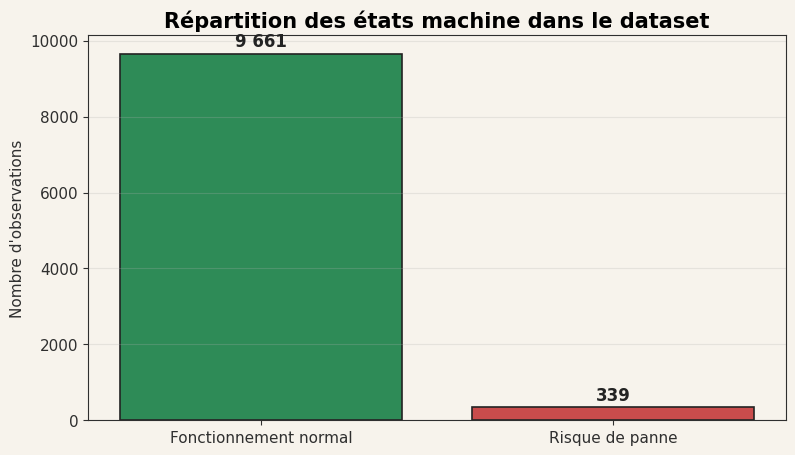

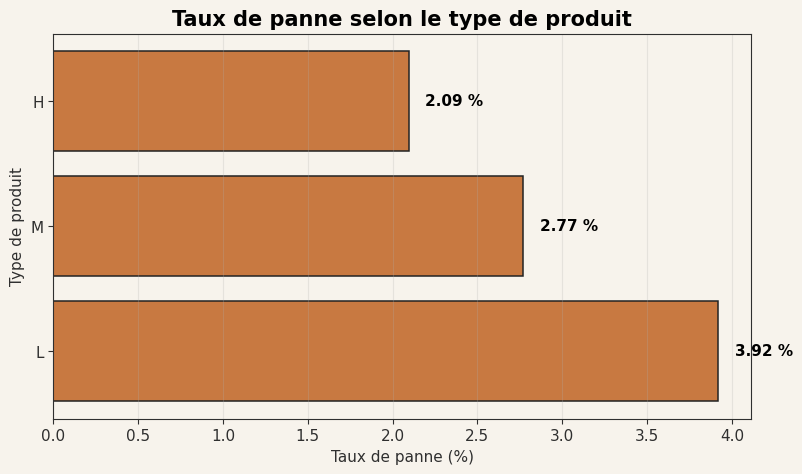

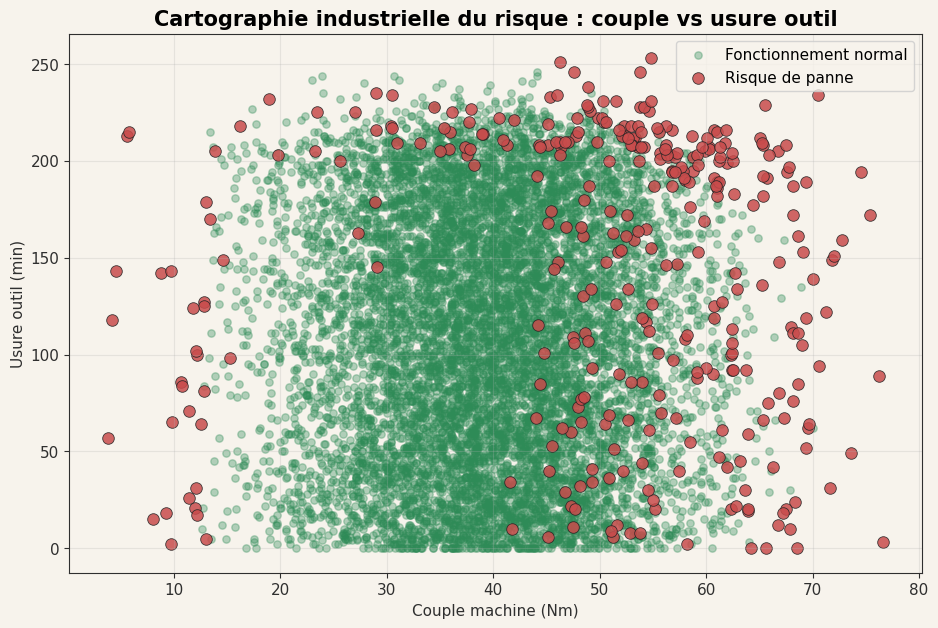

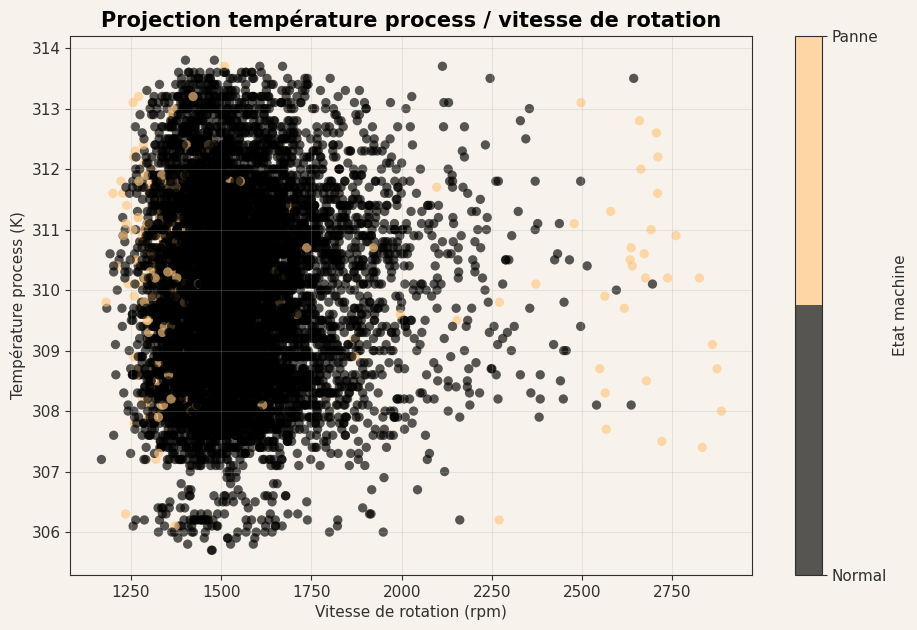

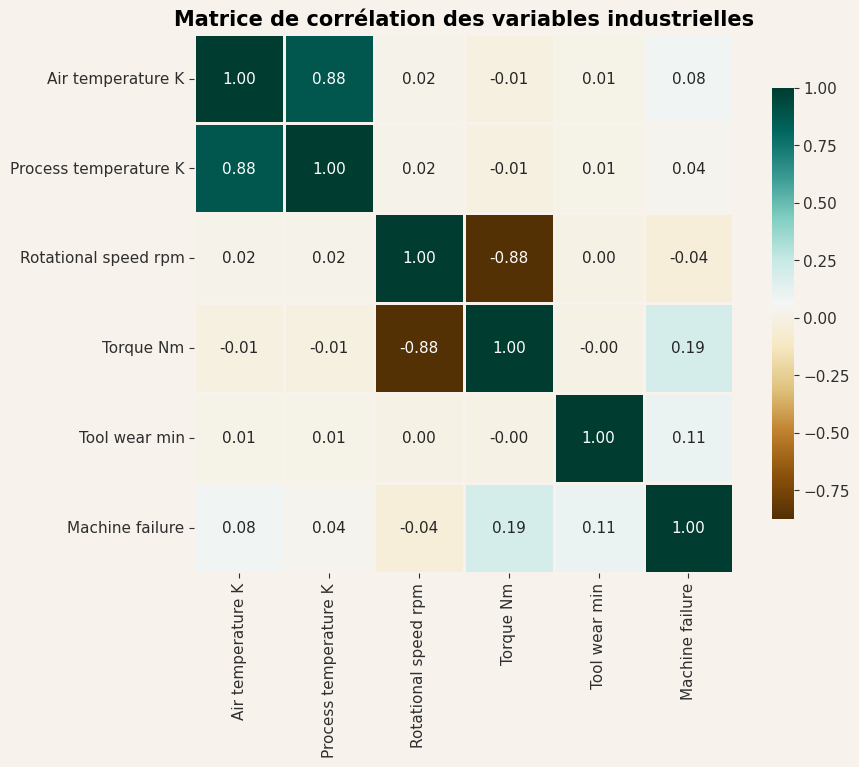

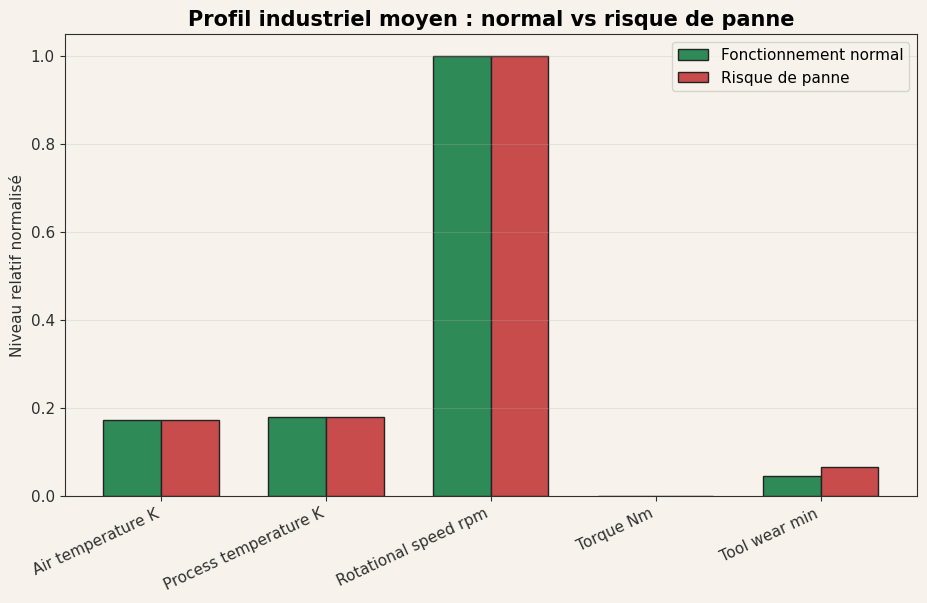

In [4]:
# ============================================================
# 3. ANALYSE EXPLORATOIRE VISUELLE
# ============================================================

# Copie de travail
eda = df_model.copy()

# Renommage de la cible pour les graphiques
eda["Etat machine"] = eda["Machine failure"].map({
    0: "Fonctionnement normal",
    1: "Risque de panne"
})

# Variables numériques industrielles
numeric_features = [
    "Air temperature K",
    "Process temperature K",
    "Rotational speed rpm",
    "Torque Nm",
    "Tool wear min"
]

# ------------------------------------------------------------
# 1. Répartition de la variable cible
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

counts = eda["Etat machine"].value_counts()
colors = [palette_innomoov["normal"], palette_innomoov["failure"]]

bars = ax.bar(
    counts.index,
    counts.values,
    color=colors,
    edgecolor=palette_innomoov["dark"],
    linewidth=1.2
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 80,
        f"{height:,}".replace(",", " "),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=palette_innomoov["dark"]
    )

ax.set_title("Répartition des états machine dans le dataset", fontsize=15)
ax.set_ylabel("Nombre d'observations")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)

plt.show()

# ------------------------------------------------------------
# 2. Taux de panne par type de produit
# ------------------------------------------------------------

if "Type" in eda.columns:
    type_failure = (
        eda.groupby("Type")["Machine failure"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.barh(
        type_failure.index,
        type_failure.values,
        color=palette_innomoov["accent"],
        edgecolor=palette_innomoov["dark"],
        linewidth=1.1
    )

    for i, value in enumerate(type_failure.values):
        ax.text(
            value + 0.1,
            i,
            f"{value:.2f} %",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_title("Taux de panne selon le type de produit", fontsize=15)
    ax.set_xlabel("Taux de panne (%)")
    ax.set_ylabel("Type de produit")
    ax.grid(axis="x", alpha=0.25)

    plt.show()

# ------------------------------------------------------------
# 3. Zone critique : couple vs usure outil
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

normal = eda[eda["Machine failure"] == 0]
failure = eda[eda["Machine failure"] == 1]

ax.scatter(
    normal["Torque Nm"],
    normal["Tool wear min"],
    s=28,
    alpha=0.35,
    color=palette_innomoov["normal"],
    label="Fonctionnement normal"
)

ax.scatter(
    failure["Torque Nm"],
    failure["Tool wear min"],
    s=70,
    alpha=0.85,
    color=palette_innomoov["failure"],
    edgecolor=palette_innomoov["dark"],
    linewidth=0.6,
    label="Risque de panne"
)

ax.set_title("Cartographie industrielle du risque : couple vs usure outil", fontsize=15)
ax.set_xlabel("Couple machine (Nm)")
ax.set_ylabel("Usure outil (min)")
ax.legend(frameon=True)
ax.grid(alpha=0.25)

plt.show()

# ------------------------------------------------------------
# 4. Température process vs vitesse de rotation
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    eda["Rotational speed rpm"],
    eda["Process temperature K"],
    c=eda["Machine failure"],
    cmap=plt.cm.get_cmap("copper", 2),
    s=45,
    alpha=0.65,
    edgecolor="none"
)

ax.set_title("Projection température process / vitesse de rotation", fontsize=15)
ax.set_xlabel("Vitesse de rotation (rpm)")
ax.set_ylabel("Température process (K)")
ax.grid(alpha=0.25)

cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1])
cbar.ax.set_yticklabels(["Normal", "Panne"])
cbar.set_label("Etat machine")

plt.show()

# ------------------------------------------------------------
# 5. Heatmap des corrélations
# ------------------------------------------------------------

corr_cols = numeric_features + ["Machine failure"]
corr_matrix = eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="BrBG",
    linewidths=0.8,
    linecolor="#F7F3EC",
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Matrice de corrélation des variables industrielles", fontsize=15)
plt.show()

# ------------------------------------------------------------
# 6. Profil moyen normal vs panne
# ------------------------------------------------------------

profile = (
    eda.groupby("Etat machine")[numeric_features]
    .mean()
    .T
)

profile_normalized = profile.copy()

for col in profile_normalized.columns:
    profile_normalized[col] = (
        profile_normalized[col] - profile_normalized[col].min()
    ) / (
        profile_normalized[col].max() - profile_normalized[col].min()
    )

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(profile_normalized.index))
width = 0.35

ax.bar(
    x - width / 2,
    profile_normalized["Fonctionnement normal"],
    width,
    label="Fonctionnement normal",
    color=palette_innomoov["normal"],
    edgecolor=palette_innomoov["dark"]
)

ax.bar(
    x + width / 2,
    profile_normalized["Risque de panne"],
    width,
    label="Risque de panne",
    color=palette_innomoov["failure"],
    edgecolor=palette_innomoov["dark"]
)

ax.set_title("Profil industriel moyen : normal vs risque de panne", fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(profile_normalized.index, rotation=25, ha="right")
ax.set_ylabel("Niveau relatif normalisé")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.show()

---

# 4. Interprétation de l’analyse exploratoire

L’analyse exploratoire montre que le problème de classification est réaliste mais difficile.

On observe d’abord que la variable cible est fortement déséquilibrée : les situations normales sont beaucoup plus nombreuses que les situations de panne. C’est typique d’un contexte industriel réel, car une panne reste un événement rare, mais critique.

Les graphiques montrent également que certaines zones de fonctionnement sont plus sensibles. En particulier, les combinaisons entre le couple machine, l’usure outil, la température process et la vitesse de rotation peuvent révéler des comportements à risque.

Dans le contexte InnoMoov, ces variables peuvent être remontées automatiquement par les machines vers le MES via une architecture OPC UA. Le modèle de classification pourra donc être intégré dans une logique de supervision afin de déclencher des alertes de maintenance prédictive.

Cette étape confirme que le besoin industriel est cohérent avec une approche de classification supervisée.

---

# 5. Choix de l’algorithme avec la carte d’orientation Scikit-Learn

La carte d’orientation Scikit-Learn permet de choisir un modèle en fonction de la nature du problème.

Dans notre cas :

- nous avons plus de 50 observations ;
- nous voulons prédire une catégorie ;
- les données sont étiquetées ;
- la variable cible est binaire : normal ou panne ;
- le dataset contient moins de 100 000 lignes ;
- les variables sont numériques et catégorielles.

Le chemin suivi dans la carte Scikit-Learn est donc :

**Données disponibles → prédiction d’une catégorie → données labellisées → classification supervisée**

Parmi les algorithmes proposés, on choisit un **SVM avec noyau RBF**.

## Pourquoi un SVM RBF ?

Le SVM est pertinent pour ce TP car :

- il est adapté aux problèmes de classification supervisée ;
- il gère bien les frontières non linéaires ;
- il fonctionne bien sur des jeux de données de taille raisonnable ;
- il permet de tracer une frontière de décision claire ;
- il est cohérent avec la demande du TP.

Le noyau RBF permet au modèle de séparer des zones de fonctionnement normal et des zones de risque même lorsque la frontière n’est pas linéaire.

In [5]:
# ============================================================
# 4. PRÉPARATION DES DONNÉES ET ENTRAÎNEMENT DU MODÈLE
# ============================================================

# ------------------------------------------------------------
# Définition de la cible et des variables explicatives
# ------------------------------------------------------------

target = "Machine failure"

X = df_model.drop(columns=[target])
y = df_model[target]

# On retire éventuellement les colonnes de types de pannes détaillées
# pour éviter une fuite de données : ces colonnes décrivent directement les causes de la panne après coup.

leakage_cols = [
    "TWF", "HDF", "PWF", "OSF", "RNF",
    "TWF ", "HDF ", "PWF ", "OSF ", "RNF "
]

X = X.drop(columns=[col for col in leakage_cols if col in X.columns])

# Identification automatique des colonnes numériques et catégorielles

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numériques utilisées :", numeric_cols)
print("Variables catégorielles utilisées :", categorical_cols)

# ------------------------------------------------------------
# Séparation train / test
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Taille train :", X_train.shape)
print("Taille test :", X_test.shape)

# ------------------------------------------------------------
# Prétraitement
# - Standardisation des variables numériques
# - Encodage OneHot des variables catégorielles
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)

# ------------------------------------------------------------
# Modèle SVM RBF
# class_weight='balanced' est utilisé car les pannes sont rares.
# ------------------------------------------------------------

svm_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]
)

# Entraînement
svm_model.fit(X_train, y_train)

# Prédictions
y_pred = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, 1]

print("Modèle entraîné avec succès.")

Variables numériques utilisées : ['Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min']
Variables catégorielles utilisées : ['Type']
Taille train : (7500, 6)
Taille test : (2500, 6)
Modèle entraîné avec succès.


In [6]:
# ============================================================
# 5. ÉVALUATION DU MODÈLE
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

results = pd.DataFrame({
    "Métrique": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

display(results)

print("Rapport de classification détaillé :")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fonctionnement normal", "Risque de panne"]
))

,Métrique,Score
0,Accuracy,0.935200
1,Precision,0.322581
2,Recall,0.823529
3,F1-score,0.463576


Rapport de classification détaillé :
                       precision    recall  f1-score   support

Fonctionnement normal       0.99      0.94      0.97      2415
      Risque de panne       0.32      0.82      0.46        85

             accuracy                           0.94      2500
            macro avg       0.66      0.88      0.71      2500
         weighted avg       0.97      0.94      0.95      2500



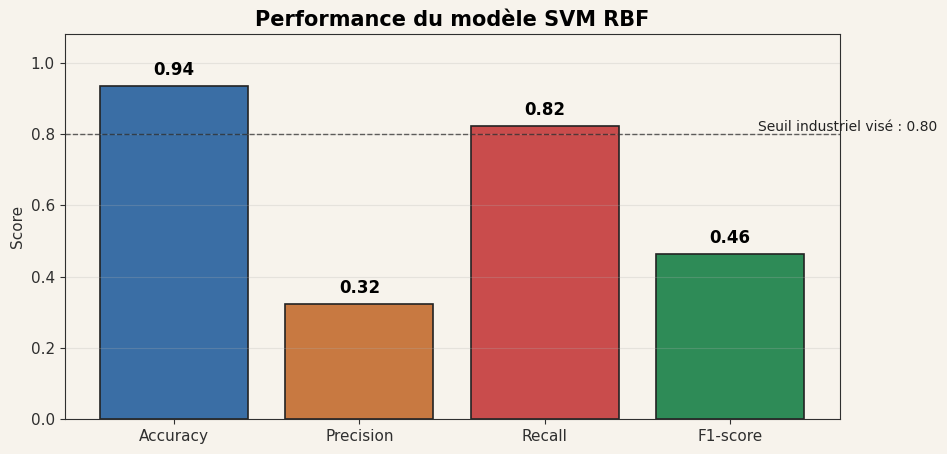

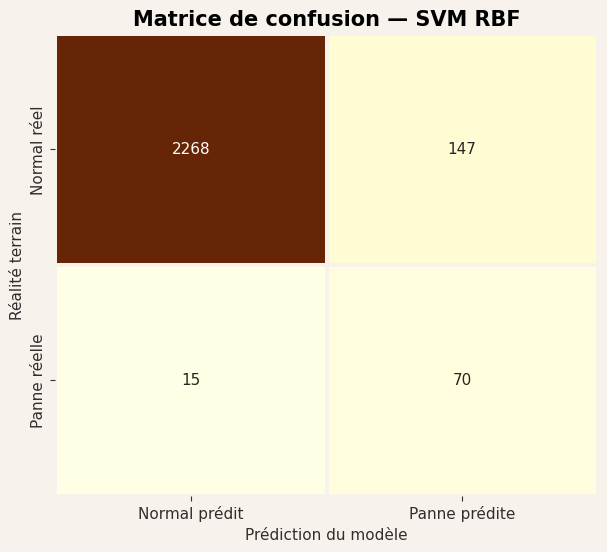

In [7]:
# ============================================================
# 6. VISUALISATION DES PERFORMANCES DU MODÈLE
# ============================================================

# ------------------------------------------------------------
# Baromètre des scores
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

score_colors = [
    palette_innomoov["blue"],
    palette_innomoov["accent"],
    palette_innomoov["failure"],
    palette_innomoov["normal"]
]

bars = ax.bar(
    results["Métrique"],
    results["Score"],
    color=score_colors,
    edgecolor=palette_innomoov["dark"],
    linewidth=1.2
)

for bar in bars:
    value = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.axhline(
    0.80,
    color=palette_innomoov["dark"],
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

ax.text(
    3.15,
    0.81,
    "Seuil industriel visé : 0.80",
    fontsize=10,
    color=palette_innomoov["dark"]
)

ax.set_ylim(0, 1.08)
ax.set_title("Performance du modèle SVM RBF", fontsize=15)
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.25)

plt.show()

# ------------------------------------------------------------
# Matrice de confusion
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrBr",
    cbar=False,
    linewidths=1.5,
    linecolor="#F7F3EC",
    xticklabels=["Normal prédit", "Panne prédite"],
    yticklabels=["Normal réel", "Panne réelle"],
    ax=ax
)

ax.set_title("Matrice de confusion — SVM RBF", fontsize=15)
ax.set_xlabel("Prédiction du modèle")
ax.set_ylabel("Réalité terrain")

plt.show()

# 6. Interprétation des performances

Le modèle SVM RBF fournit une première solution de classification supervisée pour détecter les situations de risque machine.

Dans ce contexte industriel, l’accuracy seule n’est pas suffisante, car les pannes sont rares. Une accuracy élevée peut masquer un mauvais comportement sur la classe minoritaire.

Les métriques les plus importantes sont donc :

- **Recall panne** : capacité à détecter les vraies pannes ;
- **Precision panne** : fiabilité des alertes déclenchées ;
- **F1-score** : compromis entre précision et rappel.

Pour InnoMoov, il vaut mieux détecter un maximum de pannes potentielles, même si cela génère quelques fausses alertes. Une fausse alerte coûte une vérification de maintenance, alors qu’une panne non détectée peut provoquer un arrêt de ligne, une perte de disponibilité et une baisse du TRS.

Le modèle peut donc être utilisé comme une brique de maintenance prédictive intégrée au MES ou à un dashboard de supervision.

---

# 7. Frontières de décision du modèle

Une frontière de décision représente la séparation apprise par le modèle entre deux classes :

- zone de fonctionnement normal ;
- zone de risque de panne.

Pour rendre cette frontière interprétable industriellement, on commence avec deux variables très parlantes :

- `Torque Nm` : couple mécanique demandé à la machine ;
- `Tool wear min` : usure cumulée de l’outil.

Ces deux variables sont cohérentes avec un cas de maintenance prédictive : une machine fortement sollicitée avec un outil usé peut présenter un risque plus élevé de panne ou de défaut qualité.

Score du modèle 2D : 0.82
F1-score du modèle 2D : 0.237


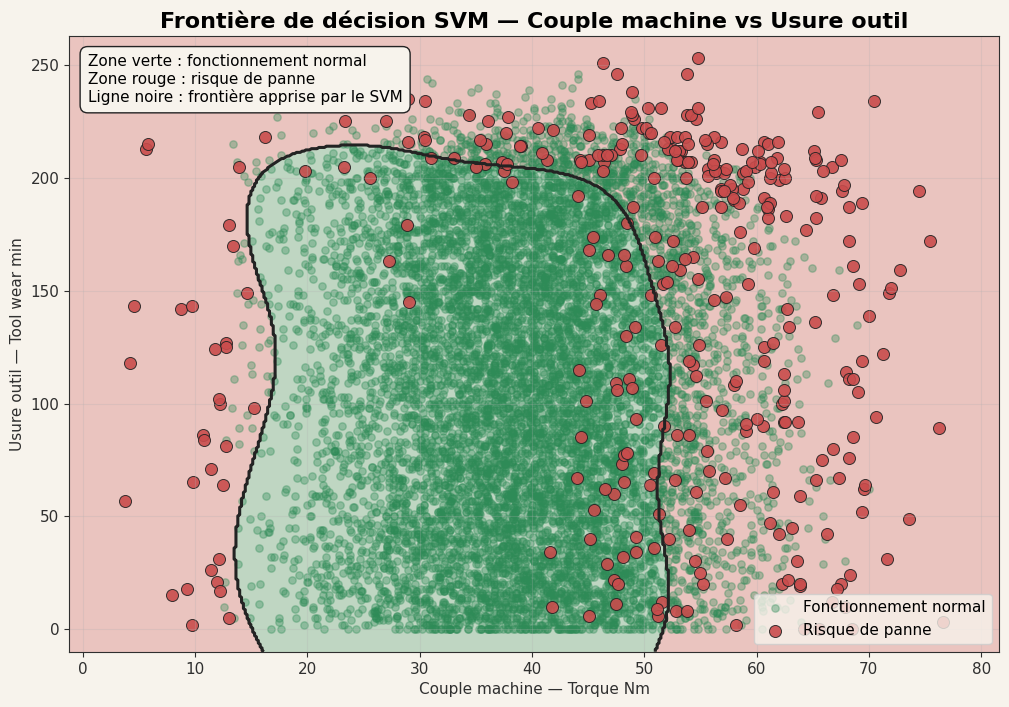

In [8]:
# ============================================================
# 7. FRONTIÈRE DE DÉCISION SUR 2 VARIABLES MÉTIER
# ============================================================

# ------------------------------------------------------------
# Sélection de deux variables industrielles interprétables
# ------------------------------------------------------------

features_2d = ["Torque Nm", "Tool wear min"]

X_2d = df_model[features_2d]
y_2d = df_model["Machine failure"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.25,
    random_state=42,
    stratify=y_2d
)

# ------------------------------------------------------------
# Pipeline spécifique pour la visualisation 2D
# ------------------------------------------------------------

svm_2d = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]
)

svm_2d.fit(X2_train, y2_train)

y2_pred = svm_2d.predict(X2_test)

print("Score du modèle 2D :", round(accuracy_score(y2_test, y2_pred), 3))
print("F1-score du modèle 2D :", round(f1_score(y2_test, y2_pred), 3))

# ------------------------------------------------------------
# Création de la grille pour afficher la frontière de décision
# ------------------------------------------------------------

x_min, x_max = X_2d["Torque Nm"].min() - 5, X_2d["Torque Nm"].max() + 5
y_min, y_max = X_2d["Tool wear min"].min() - 10, X_2d["Tool wear min"].max() + 10

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = pd.DataFrame({
    "Torque Nm": xx.ravel(),
    "Tool wear min": yy.ravel()
})

Z = svm_2d.predict(grid)
Z = Z.reshape(xx.shape)

# ------------------------------------------------------------
# Affichage de la frontière
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

ax.contourf(
    xx,
    yy,
    Z,
    alpha=0.28,
    levels=[-0.5, 0.5, 1.5],
    colors=[palette_innomoov["normal"], palette_innomoov["failure"]]
)

ax.contour(
    xx,
    yy,
    Z,
    levels=[0.5],
    colors=[palette_innomoov["dark"]],
    linewidths=2.2
)

# Points normaux
ax.scatter(
    X_2d[y_2d == 0]["Torque Nm"],
    X_2d[y_2d == 0]["Tool wear min"],
    s=28,
    alpha=0.35,
    color=palette_innomoov["normal"],
    label="Fonctionnement normal"
)

# Points panne
ax.scatter(
    X_2d[y_2d == 1]["Torque Nm"],
    X_2d[y_2d == 1]["Tool wear min"],
    s=75,
    alpha=0.9,
    color=palette_innomoov["failure"],
    edgecolor=palette_innomoov["dark"],
    linewidth=0.7,
    label="Risque de panne"
)

ax.set_title("Frontière de décision SVM — Couple machine vs Usure outil", fontsize=16)
ax.set_xlabel("Couple machine — Torque Nm")
ax.set_ylabel("Usure outil — Tool wear min")

ax.text(
    0.02,
    0.97,
    "Zone verte : fonctionnement normal\nZone rouge : risque de panne\nLigne noire : frontière apprise par le SVM",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#F7F3EC", edgecolor=palette_innomoov["dark"])
)

ax.legend(loc="lower right")
ax.grid(alpha=0.25)

plt.show()

# 8. Interprétation de la frontière de décision métier

La frontière de décision montre comment le SVM sépare les situations normales des situations à risque à partir du couple machine et de l’usure outil.

Cette visualisation est intéressante pour un responsable production ou maintenance, car elle permet d’identifier des zones critiques.

Dans une logique InnoMoov, cette frontière peut être utilisée comme une règle intelligente de supervision :

- si une machine reste dans la zone normale, elle continue à produire ;
- si elle entre dans la zone de risque, le MES peut déclencher une alerte ;
- si plusieurs alertes apparaissent sur une période courte, une intervention préventive peut être planifiée.

Cette approche permet de passer d’une maintenance réactive à une maintenance prédictive.

---

Score du modèle PCA 2D : 0.847
F1-score du modèle PCA 2D : 0.265
Variance expliquée par les deux composantes PCA : 75.03 %


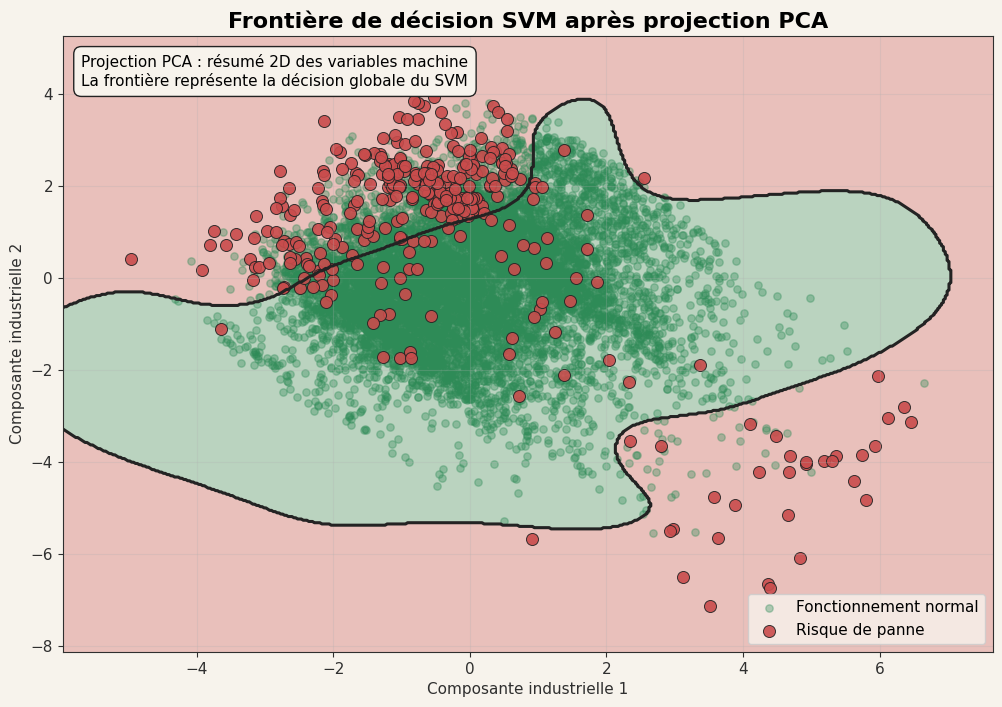

In [9]:
# ============================================================
# 8. FRONTIÈRE DE DÉCISION APRÈS RÉDUCTION PCA
# ============================================================

# ------------------------------------------------------------
# On utilise uniquement les variables numériques industrielles
# pour construire une projection PCA 2D.
# ------------------------------------------------------------

X_num = df_model[numeric_features]
y_pca = df_model["Machine failure"]

scaler_pca = StandardScaler()
X_num_scaled = scaler_pca.fit_transform(X_num)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_num_scaled)

X_pca_df = pd.DataFrame(
    X_pca,
    columns=["Composante industrielle 1", "Composante industrielle 2"]
)

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca_df,
    y_pca,
    test_size=0.25,
    random_state=42,
    stratify=y_pca
)

svm_pca = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]
)

svm_pca.fit(X_pca_train, y_pca_train)

y_pca_pred = svm_pca.predict(X_pca_test)

print("Score du modèle PCA 2D :", round(accuracy_score(y_pca_test, y_pca_pred), 3))
print("F1-score du modèle PCA 2D :", round(f1_score(y_pca_test, y_pca_pred), 3))

print(
    "Variance expliquée par les deux composantes PCA :",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

# ------------------------------------------------------------
# Création de la grille PCA
# ------------------------------------------------------------

x_min, x_max = X_pca_df["Composante industrielle 1"].min() - 1, X_pca_df["Composante industrielle 1"].max() + 1
y_min, y_max = X_pca_df["Composante industrielle 2"].min() - 1, X_pca_df["Composante industrielle 2"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid_pca = pd.DataFrame({
    "Composante industrielle 1": xx.ravel(),
    "Composante industrielle 2": yy.ravel()
})

Z_pca = svm_pca.predict(grid_pca)
Z_pca = Z_pca.reshape(xx.shape)

# ------------------------------------------------------------
# Affichage de la frontière PCA
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

ax.contourf(
    xx,
    yy,
    Z_pca,
    alpha=0.30,
    levels=[-0.5, 0.5, 1.5],
    colors=[palette_innomoov["normal"], palette_innomoov["failure"]]
)

ax.contour(
    xx,
    yy,
    Z_pca,
    levels=[0.5],
    colors=[palette_innomoov["dark"]],
    linewidths=2.2
)

ax.scatter(
    X_pca_df[y_pca == 0]["Composante industrielle 1"],
    X_pca_df[y_pca == 0]["Composante industrielle 2"],
    s=28,
    alpha=0.35,
    color=palette_innomoov["normal"],
    label="Fonctionnement normal"
)

ax.scatter(
    X_pca_df[y_pca == 1]["Composante industrielle 1"],
    X_pca_df[y_pca == 1]["Composante industrielle 2"],
    s=75,
    alpha=0.90,
    color=palette_innomoov["failure"],
    edgecolor=palette_innomoov["dark"],
    linewidth=0.7,
    label="Risque de panne"
)

ax.set_title("Frontière de décision SVM après projection PCA", fontsize=16)
ax.set_xlabel("Composante industrielle 1")
ax.set_ylabel("Composante industrielle 2")

ax.text(
    0.02,
    0.97,
    "Projection PCA : résumé 2D des variables machine\nLa frontière représente la décision globale du SVM",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#F7F3EC", edgecolor=palette_innomoov["dark"])
)

ax.legend(loc="lower right")
ax.grid(alpha=0.25)

plt.show()

---

# 9. Passage aux prédictions industrielles

Après l’entraînement et la visualisation des frontières de décision, le modèle peut maintenant être utilisé pour prédire le risque de panne sur de nouvelles situations machine.

L’objectif n’est pas seulement d’obtenir un score, mais de montrer l’intérêt concret de l’algorithme dans le process industriel InnoMoov.

Le modèle peut être utilisé pour :

- surveiller les machines en temps réel ;
- détecter les situations à risque ;
- déclencher une alerte de maintenance ;
- prioriser les interventions ;
- réduire les arrêts non planifiés ;
- améliorer le TRS ;
- fiabiliser la production des modules intelligents.

La cellule suivante va simuler plusieurs machines et demander au modèle de prédire leur état.

---

# 10. Utilisation du modèle pour des prédictions industrielles

Le modèle entraîné peut maintenant être utilisé pour prédire l’état de nouvelles machines.

Dans un contexte InnoMoov, ces données pourraient provenir directement :

- des capteurs machine ;
- du MES ;
- d’un serveur OPC UA ;
- d’un dashboard Node-RED ;
- d’un système de supervision temps réel.

L’objectif est de transformer des mesures industrielles en décision opérationnelle :

- fonctionnement normal ;
- risque de panne ;
- alerte maintenance ;
- planification d’une intervention préventive.

In [10]:
# ============================================================
# 9. PRÉDICTIONS SUR DE NOUVELLES SITUATIONS INDUSTRIELLES
# ============================================================

# ------------------------------------------------------------
# Création de scénarios industriels réalistes
# ------------------------------------------------------------

scenarios = pd.DataFrame([
    {
        "Type": "L",
        "Air temperature K": 298.5,
        "Process temperature K": 308.6,
        "Rotational speed rpm": 1550,
        "Torque Nm": 35.0,
        "Tool wear min": 45
    },
    {
        "Type": "M",
        "Air temperature K": 300.8,
        "Process temperature K": 310.5,
        "Rotational speed rpm": 1420,
        "Torque Nm": 52.0,
        "Tool wear min": 170
    },
    {
        "Type": "H",
        "Air temperature K": 302.2,
        "Process temperature K": 312.1,
        "Rotational speed rpm": 1280,
        "Torque Nm": 62.0,
        "Tool wear min": 220
    },
    {
        "Type": "L",
        "Air temperature K": 297.9,
        "Process temperature K": 308.0,
        "Rotational speed rpm": 1650,
        "Torque Nm": 28.0,
        "Tool wear min": 20
    }
])

# Sécurité : on garde exactement les mêmes colonnes que celles utilisées à l'entraînement
scenarios = scenarios[X.columns]

# ------------------------------------------------------------
# Prédictions
# ------------------------------------------------------------

predictions = svm_model.predict(scenarios)
probabilities = svm_model.predict_proba(scenarios)[:, 1]

resultats_scenarios = scenarios.copy()
resultats_scenarios["Probabilité de panne"] = probabilities
resultats_scenarios["Classe prédite"] = predictions
resultats_scenarios["Diagnostic"] = resultats_scenarios["Classe prédite"].map({
    0: "Fonctionnement normal",
    1: "Risque de panne"
})

resultats_scenarios["Décision maintenance"] = np.where(
    resultats_scenarios["Probabilité de panne"] >= 0.70,
    "Intervention préventive prioritaire",
    np.where(
        resultats_scenarios["Probabilité de panne"] >= 0.40,
        "Surveillance renforcée",
        "Production autorisée"
    )
)

display(resultats_scenarios)

,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Probabilité de panne,Classe prédite,Diagnostic,Décision maintenance
0,L,298.5,308.6,1550,35.0,45,0.000122,0,Fonctionnement normal,Production autorisée
1,M,300.8,310.5,1420,52.0,170,0.003979,0,Fonctionnement normal,Production autorisée
2,H,302.2,312.1,1280,62.0,220,0.539330,1,Risque de panne,Surveillance renforcée
3,L,297.9,308.0,1650,28.0,20,0.000029,0,Fonctionnement normal,Production autorisée


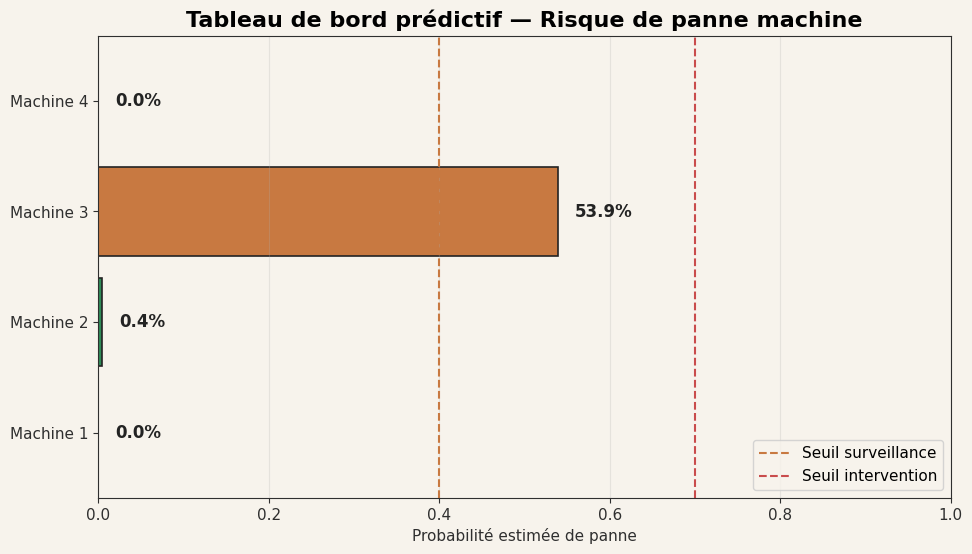

In [11]:
# ============================================================
# 10. TABLEAU DE BORD DES PRÉDICTIONS
# ============================================================

dashboard = resultats_scenarios.copy()
dashboard["Machine"] = [f"Machine {i+1}" for i in range(len(dashboard))]

fig, ax = plt.subplots(figsize=(11, 6))

colors = [
    palette_innomoov["normal"] if p < 0.40
    else palette_innomoov["accent"] if p < 0.70
    else palette_innomoov["failure"]
    for p in dashboard["Probabilité de panne"]
]

bars = ax.barh(
    dashboard["Machine"],
    dashboard["Probabilité de panne"],
    color=colors,
    edgecolor=palette_innomoov["dark"],
    linewidth=1.2
)

for bar, value in zip(bars, dashboard["Probabilité de panne"]):
    ax.text(
        value + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1%}",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=palette_innomoov["dark"]
    )

ax.axvline(
    0.40,
    color=palette_innomoov["accent"],
    linestyle="--",
    linewidth=1.5,
    label="Seuil surveillance"
)

ax.axvline(
    0.70,
    color=palette_innomoov["failure"],
    linestyle="--",
    linewidth=1.5,
    label="Seuil intervention"
)

ax.set_xlim(0, 1)
ax.set_title("Tableau de bord prédictif — Risque de panne machine", fontsize=16)
ax.set_xlabel("Probabilité estimée de panne")
ax.set_ylabel("")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.25)

plt.show()

---

# 11. Intérêt du modèle dans le process industriel InnoMoov

Le modèle de classification supervisée apporte une valeur directe au process industriel.

## 1. Maintenance prédictive

Le modèle permet d’identifier les machines à risque avant qu’une panne réelle ne se produise. Les équipes maintenance peuvent donc intervenir de manière préventive au lieu d’attendre l’arrêt de la machine.

## 2. Amélioration du TRS

Dans le projet InnoMoov, les arrêts non planifiés réduisent la disponibilité machine et dégradent le TRS. En détectant les situations à risque, le modèle contribue à réduire ces arrêts et donc à améliorer la disponibilité.

## 3. Priorisation des interventions

Toutes les alertes ne nécessitent pas la même urgence. Le modèle fournit une probabilité de panne, ce qui permet de hiérarchiser les actions :

- probabilité faible : production autorisée ;
- probabilité moyenne : surveillance renforcée ;
- probabilité élevée : intervention préventive prioritaire.

## 4. Intégration Industrie 4.0

Le modèle peut être connecté à une architecture existante :

- capteurs machine ;
- OPC UA ;
- MES ;
- ERP ;
- dashboard de supervision ;
- alertes maintenance.

Il devient ainsi une brique d’intelligence artificielle intégrée à l’usine connectée.

## 5. Impact attendu

L’utilisation du modèle permet à InnoMoov de :

- réduire les arrêts non planifiés ;
- améliorer la disponibilité machine ;
- stabiliser la production ;
- réduire les coûts de maintenance ;
- améliorer la qualité ;
- fiabiliser la livraison des modules intelligents.

Le modèle permet donc de passer d’une gestion réactive à une gestion prédictive de la maintenance.

---

In [14]:
# ============================================================
# FORMULAIRE INTERACTIF DE TEST — MAINTENANCE PRÉDICTIVE
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Widgets de saisie — version adaptée au contexte InnoMoov
# ------------------------------------------------------------

type_widget = widgets.Dropdown(
    options=[
        ("IM-Standard — module entrée de gamme", "L"),
        ("IM-Plus — module standard", "M"),
        ("IM-Premium — module haute performance", "H")
    ],
    value="M",
    description="Gamme module :",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="560px")
)

air_temp_widget = widgets.FloatSlider(
    value=300.0,
    min=295.0,
    max=305.0,
    step=0.1,
    description="Temp. atelier K :",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="560px"),
    continuous_update=False
)

process_temp_widget = widgets.FloatSlider(
    value=310.0,
    min=305.0,
    max=315.0,
    step=0.1,
    description="Temp. machine K :",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="560px"),
    continuous_update=False
)

speed_widget = widgets.IntSlider(
    value=1500,
    min=1100,
    max=2900,
    step=10,
    description="Rotation broche :",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="560px"),
    continuous_update=False
)

torque_widget = widgets.FloatSlider(
    value=40.0,
    min=3.0,
    max=80.0,
    step=0.5,
    description="Effort moteur Nm :",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="560px"),
    continuous_update=False
)

wear_widget = widgets.IntSlider(
    value=100,
    min=0,
    max=260,
    step=1,
    description="Usure outil min :",
    style={"description_width": "170px"},
    layout=widgets.Layout(width="560px"),
    continuous_update=False
)

button = widgets.Button(
    description="Analyser le risque machine",
    button_style="warning",
    icon="search",
    layout=widgets.Layout(width="260px", height="40px")
)

output = widgets.Output()

# ------------------------------------------------------------
# Fonction de prédiction
# ------------------------------------------------------------

def predict_failure(_):
    with output:
        clear_output()
        
        # Création d'une nouvelle observation machine
        new_machine = pd.DataFrame([{
            "Type": type_widget.value,
            "Air temperature K": air_temp_widget.value,
            "Process temperature K": process_temp_widget.value,
            "Rotational speed rpm": speed_widget.value,
            "Torque Nm": torque_widget.value,
            "Tool wear min": wear_widget.value
        }])
        
        # On force le même ordre de colonnes que celui utilisé à l'entraînement
        new_machine = new_machine[X.columns]
        
        # Probabilité estimée de panne
        proba = svm_model.predict_proba(new_machine)[0, 1]
        
        # Classe prédite cohérente avec la probabilité affichée
        pred = 1 if proba >= 0.50 else 0
        
        # Diagnostic selon les seuils métier
        if proba >= 0.70:
            color = "#C94C4C"
            background = "#FFF0F0"
            diagnostic = "RISQUE DE PANNE ÉLEVÉ"
            classe = "1 — Risque de panne"
            decision = "Intervention préventive prioritaire"
            message = (
                "La machine présente un risque important. "
                "Une action de maintenance doit être planifiée rapidement afin d’éviter un arrêt non planifié."
            )
        elif proba >= 0.40:
            color = "#C87941"
            background = "#FFF7EA"
            diagnostic = "RISQUE MODÉRÉ"
            classe = "0 — Fonctionnement surveillé"
            decision = "Surveillance renforcée"
            message = (
                "La machine reste exploitable, mais certains signaux indiquent une dérive possible. "
                "Une surveillance renforcée est recommandée."
            )
        else:
            color = "#2E8B57"
            background = "#F0FFF6"
            diagnostic = "FONCTIONNEMENT NORMAL"
            classe = "0 — Fonctionnement normal"
            decision = "Production autorisée"
            message = (
                "La machine fonctionne dans une zone considérée comme stable. "
                "La production peut se poursuivre normalement."
            )
        
        # Affichage HTML du résultat
        html = f"""
        <div style="
            background-color:{background};
            border:2px solid #232323;
            border-radius:16px;
            padding:22px;
            width:780px;
            font-family:Arial, sans-serif;
            box-shadow: 0px 3px 10px rgba(0,0,0,0.12);
        ">
            <h2 style="
                color:{color};
                margin-top:0;
                letter-spacing:1px;
            ">
                {diagnostic}
            </h2>

            <p style="font-size:16px;">
                <b>Probabilité estimée de panne :</b> {proba:.1%}
            </p>

            <p style="font-size:16px;">
                <b>Classe prédite :</b> {classe}
            </p>

            <p style="font-size:16px;">
                <b>Décision maintenance :</b> {decision}
            </p>

            <hr style="border:1px solid #B8B8B8;">

            <p style="font-size:15px; line-height:1.5;">
                {message}
            </p>

            <p style="font-size:14px; line-height:1.5; color:#333333;">
                Cette prédiction peut être exploitée par le MES InnoMoov pour déclencher une alerte,
                prioriser une intervention ou autoriser la poursuite de la production.
            </p>
        </div>
        """
        
        display(HTML(html))

button.on_click(predict_failure)

# ------------------------------------------------------------
# Affichage du formulaire
# ------------------------------------------------------------

form = widgets.VBox([
    widgets.HTML("""
        <h2 style="font-family:Arial; color:#232323;">
            Assistant de maintenance prédictive — Ligne InnoMoov
        </h2>
        <p style="font-family:Arial; font-size:14px; color:#444;">
            Ajustez les paramètres machine puis lancez l'analyse pour estimer le risque de panne.
        </p>
    """),
    type_widget,
    air_temp_widget,
    process_temp_widget,
    speed_widget,
    torque_widget,
    wear_widget,
    widgets.HTML("<br>"),
    button,
    widgets.HTML("<br>"),
    output
])

display(form)

---

# 12. Conclusion générale

Dans ce projet, nous avons mis en œuvre une démarche complète de classification supervisée dans un contexte Industrie 4.0.

Nous avons d’abord identifié un besoin industriel concret : prédire le risque de panne machine dans l’usine connectée InnoMoov. Ce besoin est directement lié à la maintenance prédictive, à la réduction des arrêts non planifiés et à l’amélioration du TRS.

Nous avons ensuite utilisé un dataset de maintenance prédictive contenant des variables industrielles représentatives : température, vitesse, couple, usure outil et type de produit.

À partir de la carte d’orientation Scikit-Learn, nous avons choisi un algorithme de classification supervisée adapté : le SVM avec noyau RBF. Ce choix est cohérent avec la nature du problème, la taille du dataset et la nécessité de visualiser une frontière de décision.

Le modèle a été entraîné, évalué puis interprété à l’aide de plusieurs métriques : accuracy, precision, recall et F1-score. Une attention particulière a été portée à la détection de la classe minoritaire, car les pannes sont rares mais critiques dans un environnement industriel.

Les frontières de décision ont permis de visualiser les zones de fonctionnement normal et les zones de risque, notamment à partir du couple machine et de l’usure outil.

Enfin, un formulaire interactif a été ajouté pour tester le modèle sur de nouvelles situations machine. Ce formulaire illustre comment le modèle pourrait être intégré dans un dashboard MES ou une supervision OPC UA afin d’aider les équipes de production et de maintenance à prendre de meilleures décisions.

La solution proposée montre que le Machine Learning peut devenir une brique concrète de performance industrielle pour InnoMoov : anticiper les pannes, fiabiliser la production, réduire les coûts et améliorer la disponibilité des équipements.

---